In [ ]:
#task-1
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
titanic = sns.load_dataset("titanic")
print("Dataset dimensions:", titanic.shape)
print("\nFirst 5 rows:")
print(titanic.head())
print("\nColumn names:")
print(titanic.columns)

Dataset dimensions: (891, 15)

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Column names:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'a

In [ ]:
features = [
    'survived',
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]
X = titanic[features].copy()
print("Selected Features:")
print(features)
print("\nMissing values:")
print(X.isnull().sum())

Selected Features:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

Missing values:
survived      0
pclass        0
age         177
sibsp         0
parch         0
fare          0
dtype: int64


In [ ]:
X = X.fillna(X.median())
print("Missing values after preprocessing:")
print(X.isnull().sum())
print("\nDataset shape after preprocessing:")
print(X.shape)

Missing values after preprocessing:
survived    0
pclass      0
age         0
sibsp       0
parch       0
fare        0
dtype: int64

Dataset shape after preprocessing:
(891, 6)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
titanic_df = pd.DataFrame(
    data=X_scaled,
    columns=features
)
print("Standardized dataset dimensions:", X_scaled.shape)
print("\nFirst 5 rows of standardized dataset:")
print(titanic_df.head())

Standardized dataset dimensions: (891, 6)

First 5 rows of standardized dataset:
   survived    pclass       age     sibsp     parch      fare
0 -0.789272  0.827377 -0.565736  0.432793 -0.473674 -0.502445
1  1.266990 -1.566107  0.663861  0.432793 -0.473674  0.786845
2  1.266990  0.827377 -0.258337 -0.474545 -0.473674 -0.488854
3  1.266990 -1.566107  0.433312  0.432793 -0.473674  0.420730
4 -0.789272  0.827377  0.433312 -0.474545 -0.473674 -0.486337


In [ ]:
cov_matrix = np.cov(X_scaled.T)
print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[ 1.0011236  -0.33886135 -0.06498335 -0.03536219  0.08172113  0.25759563]
 [-0.33886135  1.0011236  -0.34028024  0.08317471  0.01846339 -0.55011704]
 [-0.06498335 -0.34028024  1.0011236  -0.23355846 -0.17267575  0.09679706]
 [-0.03536219  0.08317471 -0.23355846  1.0011236   0.41530381  0.15983043]
 [ 0.08172113  0.01846339 -0.17267575  0.41530381  1.0011236   0.21646789]
 [ 0.25759563 -0.55011704  0.09679706  0.15983043  0.21646789  1.0011236 ]]


In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\nEigenvalues (Variance Components):")
print(eigenvalues)
print("\nEigenvectors (Principal Axes):")
print(eigenvectors)


Eigenvalues (Variance Components):
[1.8670329  1.63818864 0.9654988  0.35462639 0.63242388 0.54897096]

Eigenvectors (Principal Axes):
[[ 0.41580822 -0.06002199  0.72237427 -0.20853666  0.37020566 -0.34804672]
 [-0.6289134  -0.17482291  0.0653489  -0.73912078  0.15162618  0.01855747]
 [ 0.24497611  0.46113484 -0.57388815 -0.27740992  0.47975481 -0.30145119]
 [ 0.03346243 -0.61434801 -0.29541677  0.03155645 -0.20253084 -0.70154912]
 [ 0.14104026 -0.59213199 -0.19625486  0.14030226  0.6174319   0.43596388]
 [ 0.59206931 -0.15857236 -0.13700471 -0.55908509 -0.43307239  0.32467   ]]


In [ ]:
pca_model = PCA(n_components=2)
X_pca = pca_model.fit_transform(X_scaled)
pca_df = pd.DataFrame(
    data=X_pca,
    columns=['PC_1', 'PC_2']
)
print("Transformed PCA space dimensions:", X_pca.shape)
print("\nFirst 5 projected coordinates:")
print(pca_df.head())

Transformed PCA space dimensions: (891, 2)

First 5 projected coordinates:
       PC_1      PC_2
0  1.336934  0.263886
1 -2.087943 -0.393693
2  0.428932 -0.309712
3 -1.814698 -0.345435
4  1.113016 -0.751677


In [ ]:
explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.sum(explained_variance)
print("Explained Variance per Component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var * 100:.2f}%")
print(
    f"\nTotal Variance Retained by 2 Components: "
    f"{cumulative_variance * 100:.2f}%"
)

Explained Variance per Component:
PC1: 31.08%
PC2: 27.27%

Total Variance Retained by 2 Components: 58.35%


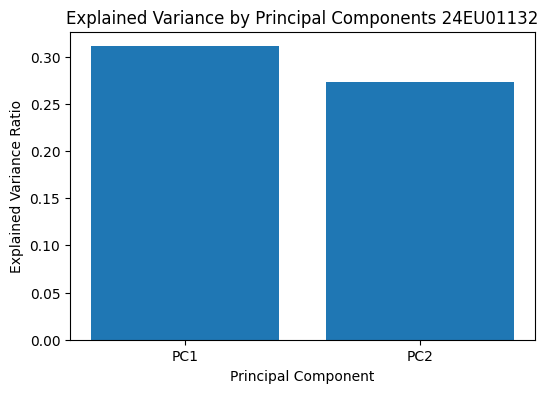

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(['PC1', 'PC2'],explained_variance)
plt.title("Explained Variance by Principal Components 24EU01132")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

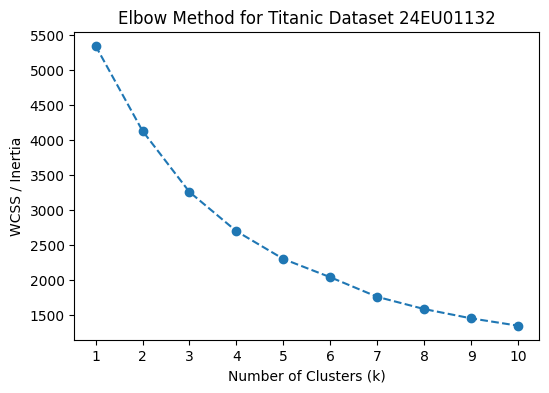

In [ ]:
#task-2
from sklearn.cluster import KMeans
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k,init='k-means++',random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(6, 4))
plt.plot(k_range,wcss,marker='o',linestyle='--')
plt.title("Elbow Method for Titanic Dataset 24EU01132")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.xticks(k_range)
plt.show()

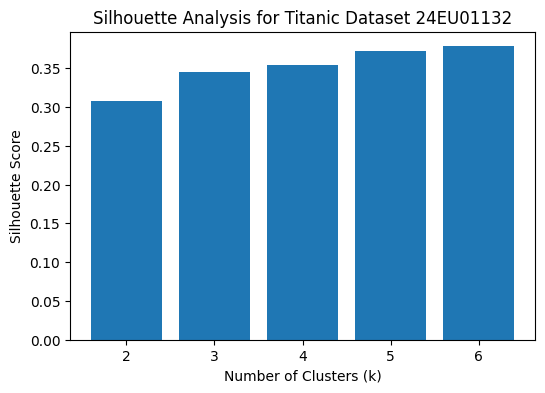

k = 6 yielded the highest silhouette coefficient (0.3782)


In [ ]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
k_eval = range(2, 7)
for k in k_eval:
    kmeans_temp = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        labels_temp
    )
    silhouette_scores.append(score)
plt.figure(figsize=(6, 4))
plt.bar(
    list(k_eval),
    silhouette_scores
)
plt.title("Silhouette Analysis for Titanic Dataset 24EU01132")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()
best_k = k_eval[np.argmax(silhouette_scores)]
print(
    f"k = {best_k} yielded the highest silhouette coefficient "
    f"({max(silhouette_scores):.4f})"
)

In [ ]:
kmeans_raw = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)
titanic_df['cluster_raw'] = kmeans_raw_labels
print("K-Means clustering completed.")
print("\nFirst 10 sample allocations:")
print(
    titanic_df[
        ['cluster_raw']
    ].head(10)
)

K-Means clustering completed.

First 10 sample allocations:
   cluster_raw
0            1
1            2
2            1
3            2
4            1
5            1
6            2
7            0
8            0
9            2


In [ ]:
raw_centroids_scaled = kmeans_raw.cluster_centers_
raw_centroids_original = scaler.inverse_transform(
    raw_centroids_scaled
)
centroids_df = pd.DataFrame(
    data=raw_centroids_original,
    columns=features
)
centroids_df.index = [
    'Cluster_0',
    'Cluster_1',
    'Cluster_2'
]
print("Estimated Cluster Centroids:")
print(centroids_df)

Estimated Cluster Centroids:
           survived    pclass        age     sibsp     parch       fare
Cluster_0  0.478261  2.565217  15.528261  2.243478  1.930435  45.958152
Cluster_1  0.200000  2.813725  28.320431  0.221569  0.092157  11.958675
Cluster_2  0.695489  1.229323  37.338346  0.357143  0.266917  65.074577


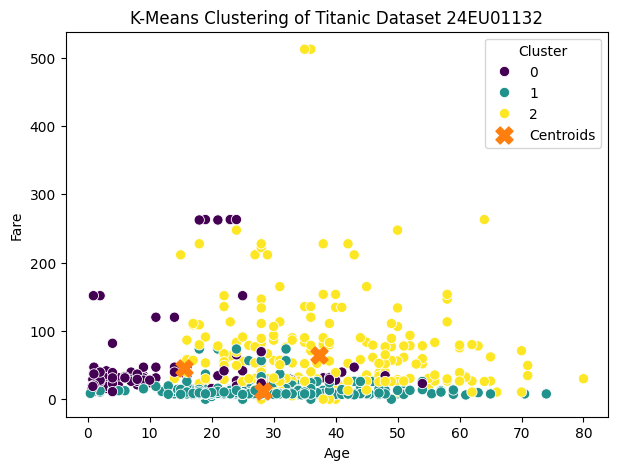

In [ ]:
raw_data = scaler.inverse_transform(X_scaled)
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=raw_data[:, 2],       # Age
    y=raw_data[:, 5],       # Fare
    hue=kmeans_raw_labels,
    palette='viridis',
    s=55
)
plt.scatter(
    raw_centroids_original[:, 2],
    raw_centroids_original[:, 5],
    marker='X',
    s=150,
    label='Centroids'
)
plt.title("K-Means Clustering of Titanic Dataset 24EU01132")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Cluster")
plt.show()

In [ ]:
#task-3
kmeans_pca = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)
titanic_df['cluster_pca'] = kmeans_pca_labels
print("PCA space K-Means clustering completed successfully.")
print("\nFirst 10 PCA cluster assignments:")
print(
    titanic_df[
        ['cluster_pca']
    ].head(10)
)

PCA space K-Means clustering completed successfully.

First 10 PCA cluster assignments:
   cluster_pca
0            0
1            1
2            0
3            1
4            0
5            0
6            1
7            2
8            2
9            0


In [ ]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score
)
sil_raw = silhouette_score(
    X_scaled,
    kmeans_raw_labels
)
ch_raw = calinski_harabasz_score(
    X_scaled,
    kmeans_raw_labels
)
sil_pca = silhouette_score(
    X_pca,
    kmeans_pca_labels
)
ch_pca = calinski_harabasz_score(
    X_pca,
    kmeans_pca_labels
)
print("==============================================")
print("INTERNAL VALIDATION")
print("==============================================")
print(
    f"Original Feature Space -> "
    f"Silhouette Score: {sil_raw:.4f} | "
    f"Calinski-Harabasz: {ch_raw:.2f}"
)
print(
    f"PCA Reduced Space     -> "
    f"Silhouette Score: {sil_pca:.4f} | "
    f"Calinski-Harabasz: {ch_pca:.2f}"
)

INTERNAL VALIDATION
Original Feature Space -> Silhouette Score: 0.3450 | Calinski-Harabasz: 285.32
PCA Reduced Space     -> Silhouette Score: 0.5244 | Calinski-Harabasz: 827.87


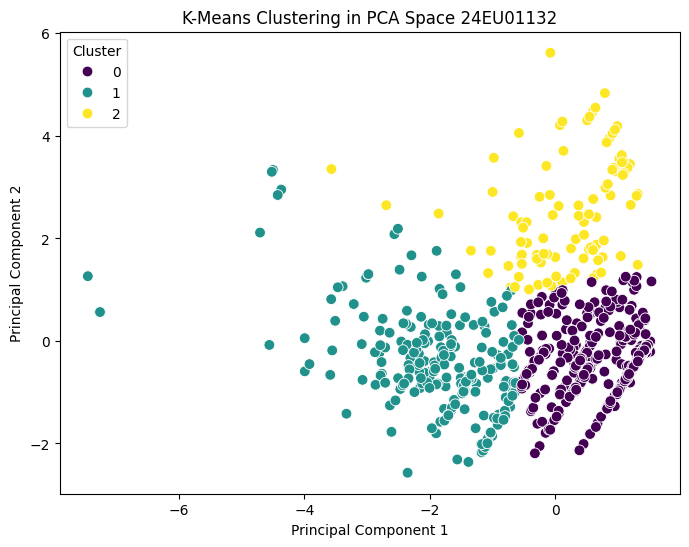

In [ ]:
pca_df['cluster'] = kmeans_pca_labels
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x='PC_1',
    y='PC_2',
    hue='cluster',
    palette='viridis',
    s=60
)
plt.title("K-Means Clustering in PCA Space 24EU01132")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Feature Space": [
        "Original Feature Space",
        "PCA Reduced Space"
    ],
    "Number of Features": [
        X_scaled.shape[1],
        X_pca.shape[1]
    ],
    "Silhouette Score": [
        sil_raw,
        sil_pca
    ],
    "Calinski-Harabasz Score": [
        ch_raw,
        ch_pca
    ]
})

print("==============================================")
print("CLUSTERING PERFORMANCE COMPARISON")
print("==============================================")
print(comparison)

CLUSTERING PERFORMANCE COMPARISON
            Feature Space  Number of Features  Silhouette Score  \
0  Original Feature Space                   6          0.344957   
1       PCA Reduced Space                   2          0.524396   

   Calinski-Harabasz Score  
0               285.323562  
1               827.869337  


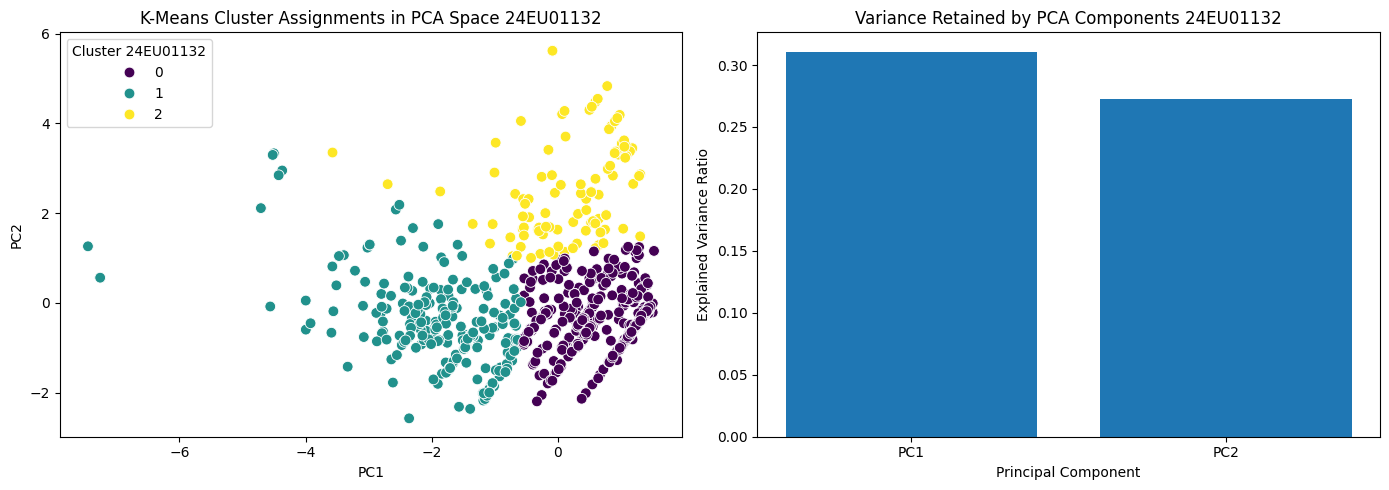

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5))
sns.scatterplot(
    data=pca_df,
    x='PC_1',
    y='PC_2',
    hue='cluster',
    palette='viridis',
    s=60,
    ax=axes[0])
axes[0].set_title(
    "K-Means Cluster Assignments in PCA Space 24EU01132")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(
    title='Cluster 24EU01132')
axes[1].bar(
    ['PC1', 'PC2'],
    explained_variance
)
axes[1].set_title(
    "Variance Retained by PCA Components 24EU01132"
)
axes[1].set_xlabel(
    "Principal Component"
)
axes[1].set_ylabel(
    "Explained Variance Ratio"
)
plt.tight_layout()
plt.show()